# Workflow Sequence Recommendation using DAG-aware Models

Этот ноутбук содержит полную реализацию и сравнение моделей для рекомендации продолжения workflow sequences в направленных ациклических графах (DAG).



<a id="установка"></a>
## Установка зависимостей


In [1]:
# Установка необходимых библиотек (раскомментируйте если нужно)
!pip install torch torch-geometric networkx numpy scikit-learn scipy pandas matplotlib seaborn

In [2]:
import json
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Добавляем путь к модулям
sys.path.insert(0, os.getcwd())

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import networkx as nx
from pathlib import Path
from collections import defaultdict, Counter
from typing import Dict, List, Tuple, Optional
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, ndcg_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch_geometric.data import Data
import matplotlib.pyplot as plt
import seaborn as sns

# Импорт функций из наших модулей
from directed_dag_models import (
    load_dag_from_json,
    extract_paths_from_compositions,
    create_training_pairs,
    split_data,
    build_graph,
    prepare_pyg,
    prepare_sequences,
    build_composition_graphs,
    popularity_baseline,
    SRGNNRecommender,
    GRU4Rec,
    train_srgnn_global_graph,
    train_gru_model,
    compute_metrics,
    build_global_srgnn_adj,
    build_srgnn_samples_from_contexts
)

from dag_transformer_integration import add_dag_transformer_to_main

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")


PyTorch version: 2.9.0+cpu
CUDA available: False


<a id="подготовка-данных"></a>
## Подготовка данных

Загружаем данные из JSON файла и преобразуем их в формат, подходящий для обучения моделей.


In [3]:
# Параметры эксперимента
EPOCHS = 50  # Для production рекомендуется 150+
MAX_LEN = 20  # Максимальная длина последовательности
HIDDEN_DIM = 64  # Размерность скрытого слоя
DROPOUT = 0.4
LEARNING_RATE = 1e-3
TEST_SIZE = 0.3
SEED = 42
BATCH_SIZE = 32
DATA_FILE = "compositionsDAG.json"

# Устанавливаем seed для воспроизводимости
torch.manual_seed(SEED)
np.random.seed(SEED)

print("="*70)
print("ПАРАМЕТРЫ ЭКСПЕРИМЕНТА")
print("="*70)
print(f"Эпох: {EPOCHS}")
print(f"Max длина последовательности: {MAX_LEN}")
print(f"Hidden dimension: {HIDDEN_DIM}")
print(f"Dropout: {DROPOUT}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Test size: {TEST_SIZE}")
print("="*70)


ПАРАМЕТРЫ ЭКСПЕРИМЕНТА
Эпох: 50
Max длина последовательности: 20
Hidden dimension: 64
Dropout: 0.4
Learning rate: 0.001
Test size: 0.3


In [4]:
# Загрузка и подготовка данных
dag, compositions = load_dag_from_json(Path(DATA_FILE))
paths_with_idx = extract_paths_from_compositions(compositions)
contexts, targets, comp_indices = create_training_pairs(paths_with_idx)

print(f"Загружено композиций: {len(compositions)}")
print(f"Извлечено путей: {len(paths_with_idx)}")
print(f"Создано training pairs: {len(contexts)}")

# Разделение на train/test
ctx_train, ctx_test, y_train, y_test, comp_train_idx, comp_test_idx = split_data(
    contexts, targets, comp_indices, TEST_SIZE, SEED
)

print(f"\nTrain set: {len(ctx_train)} samples ({len(ctx_train)/len(contexts)*100:.1f}%)")
print(f"Test set: {len(ctx_test)} samples ({len(ctx_test)/len(contexts)*100:.1f}%)")

# Построение графа
train_comp_set = set(comp_train_idx)
train_paths_only = [path for path, comp_idx in paths_with_idx if comp_idx in train_comp_set]
all_nodes = sorted({node for path, _ in paths_with_idx for node in path})

# Строим оригинальный граф для GRU4Rec
original_graph = build_graph(train_paths_only)
original_graph.add_nodes_from(all_nodes)

# Обрабатываем циклы для DAG-Transformer
from cycle_handling import build_dag_from_paths
graph = build_dag_from_paths(train_paths_only, cycle_handling="remove_weakest")
graph.add_nodes_from(all_nodes)

nodes = sorted(graph.nodes())
data_pyg, node_map = prepare_pyg(graph, nodes)

services = sorted({y for y in targets})
service_map = {svc: idx for idx, svc in enumerate(services)}

print(f"\nУзлов в графе: {len(nodes)}")
print(f"Ребер в графе: {graph.number_of_edges()}")
print(f"Уникальных сервисов: {len(services)}")

# Подготовка данных для обучения
targets_train_tensor = torch.tensor([service_map[y] for y in y_train], dtype=torch.long)
targets_test_tensor = torch.tensor([service_map[y] for y in y_test], dtype=torch.long)
train_idx = torch.tensor([node_map[ctx[-1]] for ctx in ctx_train], dtype=torch.long)
test_idx = torch.tensor([node_map[ctx[-1]] for ctx in ctx_test], dtype=torch.long)
targets_train = torch.tensor([service_map[y] for y in y_train], dtype=torch.long)
targets_test = torch.tensor([service_map[y] for y in y_test], dtype=torch.long)
train_target_indices = [service_map[y] for y in y_train]
test_target_indices = [service_map[y] for y in y_test]
service_node_indices = torch.tensor([node_map[svc] + 1 for svc in services], dtype=torch.long)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nDevice: {device}")


Загружено композиций: 943
Извлечено путей: 943
Создано training pairs: 1016

Train set: 711 samples (70.0%)
Test set: 305 samples (30.0%)

Узлов в графе: 50
Ребер в графе: 87
Уникальных сервисов: 15

Device: cpu


<a id="модель-1"></a>
# МОДЕЛЬ 1: Popularity Baseline

Простая базовая модель, которая предсказывает самый популярный сервис.


In [5]:
print("="*70)
print("МОДЕЛЬ 1: POPULARITY BASELINE")
print("="*70)

baseline_results = popularity_baseline(
    targets_train_tensor,
    targets_test_tensor,
    len(service_map),
    name="Popularity"
)

print(f"Результаты Popularity Baseline:")
print(f"Accuracy: {baseline_results['accuracy']:.4f}")
print(f"NDCG@10: {baseline_results['ndcg']:.4f}")
print(f"F1-Score: {baseline_results['f1']:.4f}")
print(f"Precision: {baseline_results['precision']:.4f}")
print(f"Recall: {baseline_results['recall']:.4f}")


МОДЕЛЬ 1: POPULARITY BASELINE
Результаты Popularity Baseline:
Accuracy: 0.4787
NDCG@10: 0.6106
F1-Score: 0.0540
Precision: 0.0399
Recall: 0.0833


<a id="модель-2"></a>
# МОДЕЛЬ 2: SR-GNN

**Session-based Recommendation with Graph Neural Networks** (Wu et al., AAAI 2019)

SR-GNN использует графовые нейронные сети для моделирования сессий пользователей.

### Архитектура:
- **Session Graph Construction**: Каждая сессия преобразуется в направленный граф
- **GNN Layer**: GRU-подобная ячейка с 3 гейтами (reset, input, new)
- **Session Representation**: Attention mechanism для агрегации элементов сессии
- **Prediction**: Dot product session representation с embeddings всех items


In [6]:
print("="*70)
print("МОДЕЛЬ 2: SR-GNN")
print("Session-based Recommendation with Graph Neural Networks")
print("Wu et al., AAAI 2019")
print("="*70)

# Создание модели SR-GNN
srgnn_model = SRGNNRecommender(
    num_nodes=len(node_map),
    hidden=128,
    step=1,
    non_hybrid=False
)
srgnn_optimizer = torch.optim.Adam(srgnn_model.parameters(), lr=5e-4)

print("\nНачало обучения SR-GNN...")
srgnn_results = train_srgnn_global_graph(
    srgnn_model,
    node_map,
    data_pyg,
    ctx_train,
    ctx_test,
    train_target_indices,
    test_target_indices,
    service_node_indices,
    srgnn_optimizer,
    EPOCHS,
    "SR-GNN",
    device
)

print(f"Результаты SR-GNN:")
print(f"Accuracy: {srgnn_results['accuracy']:.4f}")
print(f"NDCG@10: {srgnn_results['ndcg']:.4f}")
print(f"F1-Score: {srgnn_results['f1']:.4f}")
print(f"Precision: {srgnn_results['precision']:.4f}")
print(f"Recall: {srgnn_results['recall']:.4f}")


МОДЕЛЬ 2: SR-GNN
Session-based Recommendation with Graph Neural Networks
Wu et al., AAAI 2019

Начало обучения SR-GNN...
Результаты SR-GNN:
Accuracy: 0.5443
NDCG@10: 0.7695
F1-Score: 0.2145
Precision: 0.2015
Recall: 0.2526


<a id="модель-3"></a>
# МОДЕЛЬ 3: GRU4Rec

**Session-based Recommendations with Recurrent Neural Networks** (Hidasi et al., ICLR 2016)

GRU4Rec использует рекуррентные нейронные сети (GRU) для моделирования последовательностей.

### Архитектура:
- **Embedding Layer**: Embedding для items с отдельным dropout (0.25)
- **GRU Layer**: Многослойный GRU с dropout только между слоями
- **Output Layer**: Linear layer для предсказания следующего item
- **DAG Masking**: Маскирование выходов по структуре DAG (уникальная добавка)


In [7]:
print("="*70)
print("МОДЕЛЬ 3: GRU4Rec")
print("Session-based Recommendations with Recurrent Neural Networks")
print("Hidasi et al., ICLR 2016")
print("="*70)

# Подготовка данных для GRU4Rec
print("\nПодготовка данных для GRU4Rec...")
seq_all, len_all, labels_all = prepare_sequences(
    contexts, targets, node_map, service_map, max_len=MAX_LEN
)

label_counts = Counter(labels_all.numpy())
min_seq_count = min(label_counts.values())
stratify_seq = labels_all.numpy() if min_seq_count >= 2 else None

seq_train, seq_test, len_train, len_test, lab_train, lab_test = train_test_split(
    seq_all, len_all, labels_all,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=stratify_seq
)

last_nodes_train = torch.tensor([node_map[ctx[-1]] for ctx in ctx_train], dtype=torch.long)
last_nodes_test = torch.tensor([node_map[ctx[-1]] for ctx in ctx_test], dtype=torch.long)

# Построение DAG successors для masking
successors = defaultdict(list)
successor_nodes = defaultdict(list)
for u, v in original_graph.edges():
    if u in node_map and v in node_map:
        if v.startswith("service") and v in service_map:
            successors[node_map[u]].append(service_map[v])
        successor_nodes[node_map[u]].append(node_map[v])

# Создание модели GRU4Rec
gru_model = GRU4Rec(
    num_nodes=len(node_map),
    num_services=len(service_map),
    embedding_dim=64,
    hidden=HIDDEN_DIM * 2,
    num_layers=2,
    dropout_embed=0.25,
    dropout_hidden=0.4,
    dag_successors=successors,
    dag_successor_nodes=successor_nodes
)
gru_optimizer = torch.optim.Adam(gru_model.parameters(), lr=LEARNING_RATE)

print("Начало обучения GRU4Rec...")
gru_results = train_gru_model(
    gru_model, seq_train, len_train, seq_test, len_test,
    lab_train, lab_test, last_nodes_train, last_nodes_test,
    gru_optimizer, EPOCHS, loss_type='ce', n_sample=0, sample_alpha=0.75
)

print(f"\nРезультаты GRU4Rec:")
print(f"Accuracy: {gru_results['accuracy']:.4f}")
print(f"NDCG@10: {gru_results['ndcg']:.4f}")
print(f"F1-Score: {gru_results['f1']:.4f}")
print(f"Precision: {gru_results['precision']:.4f}")
print(f"Recall: {gru_results['recall']:.4f}")


МОДЕЛЬ 3: GRU4Rec
Session-based Recommendations with Recurrent Neural Networks
Hidasi et al., ICLR 2016

Подготовка данных для GRU4Rec...
Начало обучения GRU4Rec...

Результаты GRU4Rec:
Accuracy: 0.5344
NDCG@10: 0.7664
F1-Score: 0.2241
Precision: 0.3219
Recall: 0.2625


<a id="модель-4"></a>
# МОДЕЛЬ 4: DAG-Transformer

**Transformer-based model with DAG-aware attention mechanism**

DAG-Transformer использует архитектуру Transformer с учетом структуры DAG через специальные механизмы внимания.

### Архитектура:
- **Depth-Aware Embedding**: Node embeddings с учетом глубины узла в DAG
- **Topological Positional Encoding**: Позиционное кодирование на основе топологического порядка
- **DAG-Aware Attention Mask**: Attention mask разрешает внимание только к предшественникам
- **Transformer Blocks**: Multi-head self-attention с feed-forward сетями
- **Output Head**: Предсказание следующего сервиса


In [17]:
print("="*70)
print("МОДЕЛЬ 4: DAG-Transformer")
print("Transformer-based model with DAG-aware attention mechanism")
print("="*70)

class Args:
    def __init__(self):
        self.max_len = MAX_LEN
        self.hidden = HIDDEN_DIM
        self.dropout = DROPOUT
        self.epochs = 200
        self.lr = LEARNING_RATE

args = Args()

print("Начало обучения DAG-Transformer...")
dag_transformer_results = add_dag_transformer_to_main(
    ctx_train, ctx_test, y_train, y_test,
    node_map, service_map, data_pyg, args, device,
    graph=graph, original_graph=original_graph
)

print(f"\nРезультаты DAG-Transformer:")
print(f"Accuracy: {dag_transformer_results['accuracy']:.4f}")
print(f"NDCG@10: {dag_transformer_results['ndcg']:.4f}")
print(f"F1-Score: {dag_transformer_results['f1']:.4f}")
print(f"Precision: {dag_transformer_results['precision']:.4f}")
print(f"Recall: {dag_transformer_results['recall']:.4f}")

МОДЕЛЬ 4: DAG-Transformer
Transformer-based model with DAG-aware attention mechanism
Начало обучения DAG-Transformer...
DAG-Transformer Epoch 10/200, Loss: 1.8965
DAG-Transformer Epoch 20/200, Loss: 1.5248
DAG-Transformer Epoch 30/200, Loss: 1.4103
DAG-Transformer Epoch 40/200, Loss: 1.2966
DAG-Transformer Epoch 50/200, Loss: 1.2814
DAG-Transformer Epoch 60/200, Loss: 1.2579
DAG-Transformer Epoch 70/200, Loss: 1.2451
DAG-Transformer Epoch 80/200, Loss: 1.2042
DAG-Transformer Epoch 90/200, Loss: 1.2293
DAG-Transformer Epoch 100/200, Loss: 1.1985
DAG-Transformer Epoch 110/200, Loss: 1.1776
DAG-Transformer Epoch 120/200, Loss: 1.1687
DAG-Transformer Epoch 130/200, Loss: 1.1820
DAG-Transformer Epoch 140/200, Loss: 1.1557
DAG-Transformer Epoch 150/200, Loss: 1.1567
DAG-Transformer Epoch 160/200, Loss: 1.1310
DAG-Transformer Epoch 170/200, Loss: 1.1292
DAG-Transformer Epoch 180/200, Loss: 1.1215
DAG-Transformer Epoch 190/200, Loss: 1.1312
DAG-Transformer Epoch 200/200, Loss: 1.1339

Результа

<a id="сравнение"></a>
# СРАВНЕНИЕ РЕЗУЛЬТАТОВ

Создаем наглядные таблицы и графики для сравнения всех моделей.


In [18]:
# Собираем все результаты
all_results = {
    "Popularity": baseline_results,
    "SR-GNN": srgnn_results,
    "GRU4Rec": gru_results,
    "DAG-Transformer": dag_transformer_results
}

# Создаем DataFrame для удобного отображения
results_df = pd.DataFrame(all_results).T
results_df = results_df[['accuracy', 'ndcg', 'f1', 'precision', 'recall']]
results_df.columns = ['Accuracy', 'NDCG@10', 'F1-Score', 'Precision', 'Recall']

print("="*70)
print("ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*70)
print(results_df.round(4).to_string())
print("="*70)

ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
                 Accuracy  NDCG@10  F1-Score  Precision  Recall
Popularity         0.4787   0.6106    0.0540     0.0399  0.0833
SR-GNN             0.5443   0.7695    0.2145     0.2015  0.2526
GRU4Rec            0.5344   0.7664    0.2241     0.3219  0.2625
DAG-Transformer    0.5410   0.7704    0.3696     0.3579  0.4065


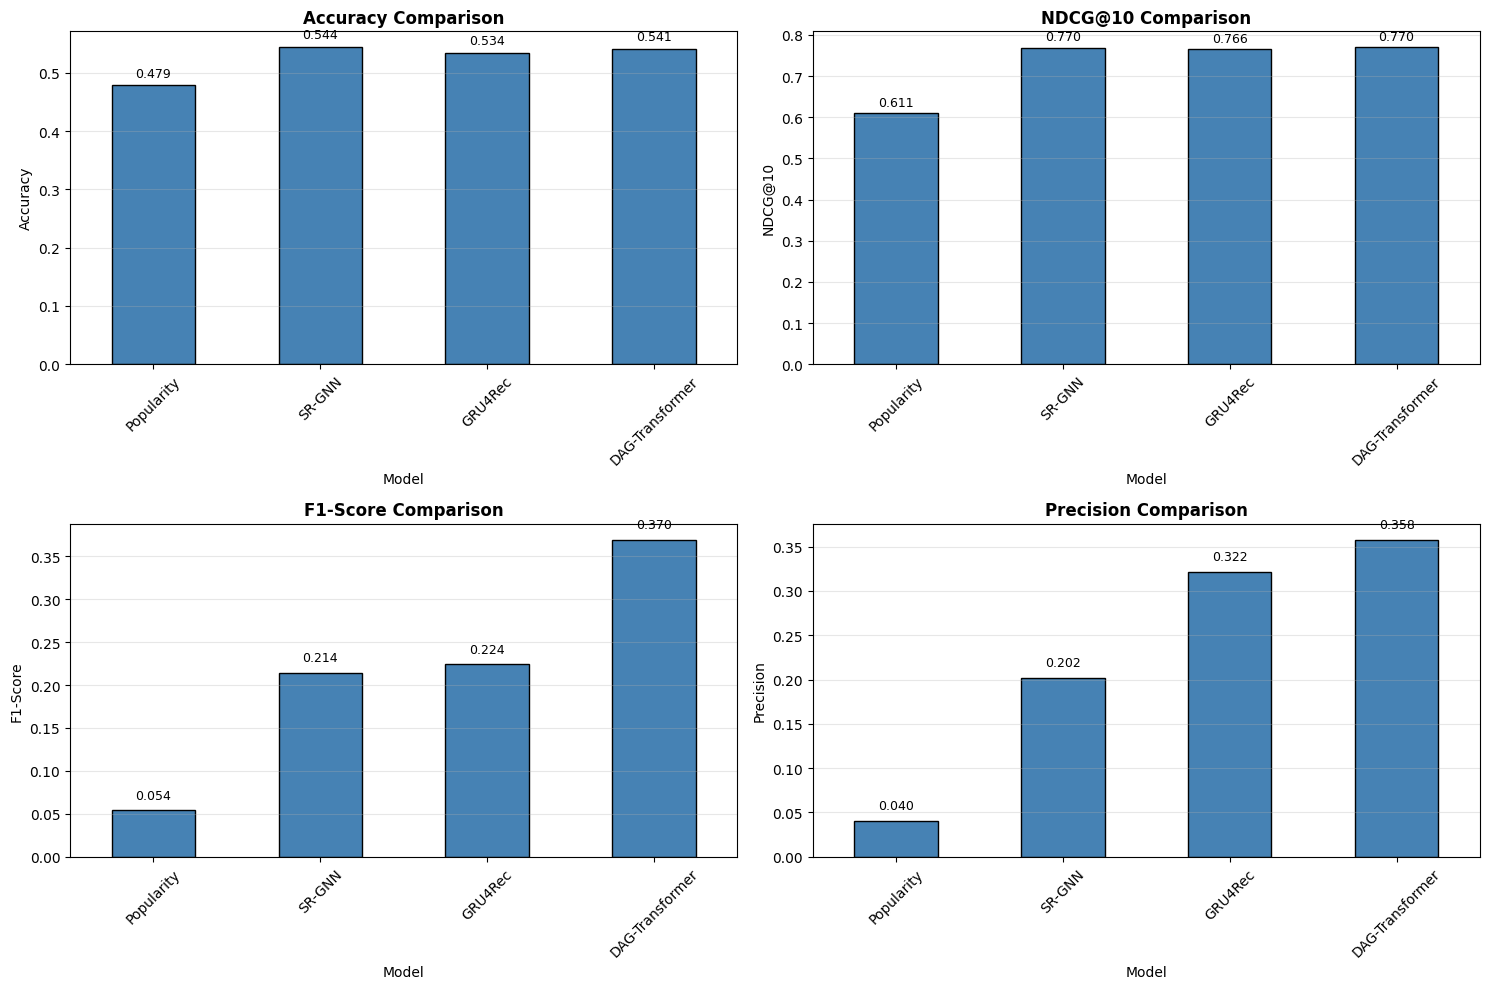

In [19]:
# Визуализация результатов - столбчатые диаграммы
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics_to_plot = ['Accuracy', 'NDCG@10', 'F1-Score', 'Precision']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    results_df[metric].plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric, fontsize=10)
    ax.set_xlabel('Model', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

    # Добавляем значения на столбцы
    for i, v in enumerate(results_df[metric]):
        ax.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

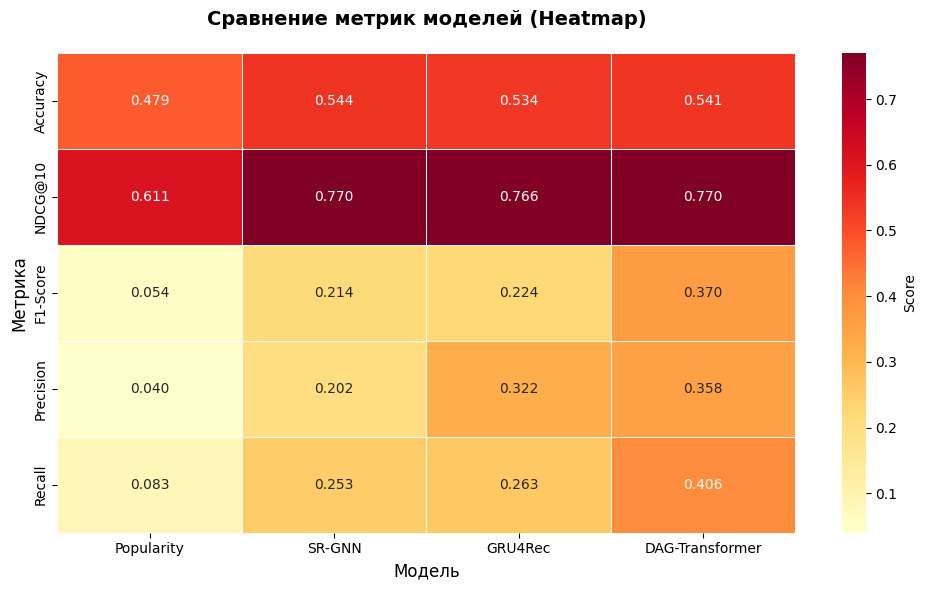

In [20]:
# Heatmap сравнения
plt.figure(figsize=(10, 6))
sns.heatmap(results_df.T, annot=True, fmt='.3f', cmap='YlOrRd',
            cbar_kws={'label': 'Score'}, linewidths=0.5)
plt.title('Сравнение метрик моделей (Heatmap)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Модель', fontsize=12)
plt.ylabel('Метрика', fontsize=12)
plt.tight_layout()
plt.show()

In [21]:
# Ранжирование моделей по каждой метрике
print("="*70)
print("РАНЖИРОВАНИЕ МОДЕЛЕЙ")
print("="*70)

for metric in ['Accuracy', 'NDCG@10', 'F1-Score']:
    ranked = results_df[metric].sort_values(ascending=False)
    print(f"\n{metric}:")
    for rank, (model, score) in enumerate(ranked.items(), 1):
        print(f"  {rank}. {model:20s}: {score:.4f}")

print("\n" + "="*70)

РАНЖИРОВАНИЕ МОДЕЛЕЙ

Accuracy:
  1. SR-GNN              : 0.5443
  2. DAG-Transformer     : 0.5410
  3. GRU4Rec             : 0.5344
  4. Popularity          : 0.4787

NDCG@10:
  1. DAG-Transformer     : 0.7704
  2. SR-GNN              : 0.7695
  3. GRU4Rec             : 0.7664
  4. Popularity          : 0.6106

F1-Score:
  1. DAG-Transformer     : 0.3696
  2. GRU4Rec             : 0.2241
  3. SR-GNN              : 0.2145
  4. Popularity          : 0.0540

